# Tourist digital behavior in the Canary Islands (2018-2020)

**Dataset**: Turistas de 16 y mas anos segun si han usado en Canarias un smartphone o tablet con conexion a internet

**Source**: [ISTAC](https://datos.canarias.es) - quarterly survey of tourists 16+ about smartphone/tablet usage with internet connection in the Canary Islands, by accommodation type

**Question**: How has tourist digital connectivity evolved? Which accommodation types have the highest connected tourist rates? What does the COVID-19 onset look like in Q1 2020?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
OUTPUT_DIR = Path("output/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = "data/raw/tourist-digital-behavior-canary-islands.csv"
df = pd.read_csv(CSV_PATH)
print("Rows:", len(df), "| Columns:", len(df.columns))
print("Time range:", df["TIME_PERIOD_CODE"].min(), "->", df["TIME_PERIOD_CODE"].max())
df.head(2)

Rows: 672 | Columns: 14
Time range: 2018 -> 2020-Q1


,TERRITORIO#es,TERRITORIO_CODE,TIME_PERIOD#es,TIME_PERIOD_CODE,CONEXION_INTERNET#es,CONEXION_INTERNET_CODE,MEDIDAS#es,MEDIDAS_CODE,TIPO_ALOJAMIENTO#es,TIPO_ALOJAMIENTO_CODE,OBS_VALUE,NOTAS_OBSERVACION,ESTADO_OBSERVACION#es,CONFIDENCIALIDAD_OBSERVACION#es
0,Canarias,ES70,2018 Primer trimestre,2018-Q1,Sin especificar tipo de conexión,SIN_ESPECIFICAR,Turistas,TURISTAS,Otros,_O,17862,NaN,NaN,NaN
1,Canarias,ES70,2018 Segundo trimestre,2018-Q2,Sin especificar tipo de conexión,SIN_ESPECIFICAR,Turistas,TURISTAS,Otros,_O,17672,NaN,NaN,NaN


In [2]:
# Rename columns for convenience
df = df.rename(columns={
    "TIPO_ALOJAMIENTO#es": "accommodation",
    "TIPO_ALOJAMIENTO_CODE": "accommodation_code",
    "CONEXION_INTERNET#es": "connection",
    "CONEXION_INTERNET_CODE": "connection_code",
    "TIME_PERIOD_CODE": "period",
    "OBS_VALUE": "tourists"
})

# Parse quarter - periods like 2018, 2018-Q1, 2018-Q2...
# is_quarter: True for quarterly data, False for annual totals
df["is_quarter"] = df["period"].str.contains("Q", na=False)
df["year"] = df["period"].str[:4].astype(int)
df["quarter"] = df["period"].str.extract(r"Q(\d)")[0]
df["quarter"] = pd.to_numeric(df["quarter"], errors="coerce")

# Build date string with proper int conversion (quarter can be float like 1.0)
# Q1=Jan, Q2=Apr, Q3=Jul, Q4=Oct
df["month"] = (df["quarter"] * 3 - 2).astype("Int64")
df["date_str"] = df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2) + "-01"
df["date"] = pd.to_datetime(df["date_str"], errors="coerce")

print("Accommodation types:")
for a in sorted(df["accommodation"].unique()):
    print(" -", a)
print()
print("Connection types:")
for c in sorted(df["connection"].unique()):
    print(" -", c)

Accommodation types:
 - Apartamento o villa turística
 - Hotel 1, 2 y 3 Estrellas
 - Hotel 4 Estrellas
 - Hotel 5 Estrellas
 - Otros
 - Total
 - Vivienda de amigos o familiares o vivienda propia o intercambio gratuito de vivienda u otros alojamientos privados
 - Vivienda o habitación alquilada a un particular

Connection types:
 - Con ambas conexiones
 - Con mi conexión a Internet
 - Con mi conexión a Wifi gratuito
 - NO
 - SI
 - Sin especificar tipo de conexión
 - Total


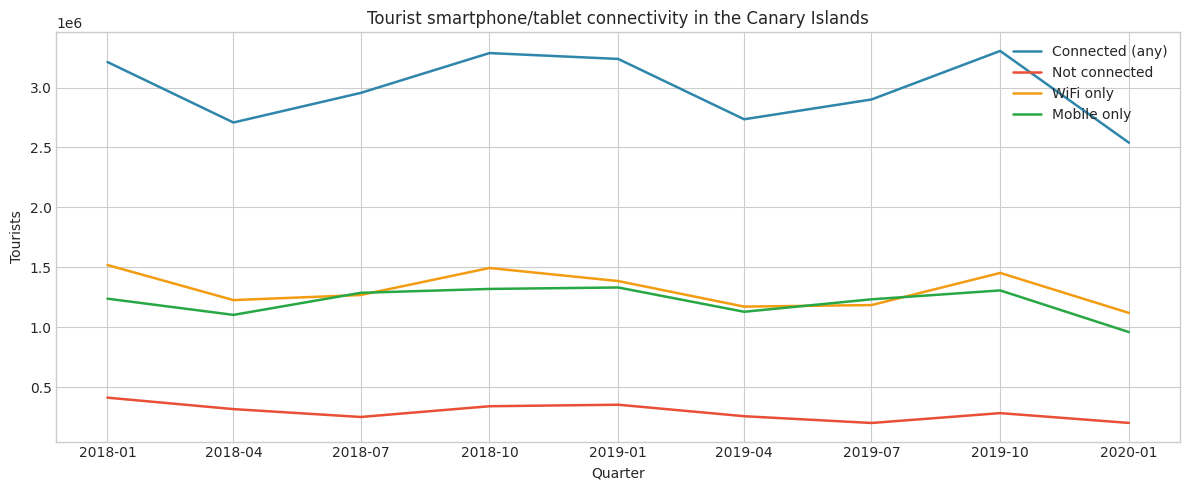

Saved: output/figures/tourist_digital_total_trend.png


In [3]:
# 1. Total connected tourists (SI) - quarterly trend
total = df[(df["accommodation_code"] == "_T") & (df["is_quarter"] == True)]

fig, ax = plt.subplots(figsize=(12, 5))

for conn_code, conn_name, color in [
    ("SI", "Connected (any)", "#2E86AB"),
    ("NO", "Not connected", "#E94F37"),
    ("WIFI", "WiFi only", "#F39C12"),
    ("INTERNET", "Mobile only", "#28A745")
]:
    d = total[total["connection_code"] == conn_code].dropna(subset=["date"]).sort_values("date")
    if len(d) > 0:
        ax.plot(d["date"], d["tourists"], label=conn_name, color=color, linewidth=1.8)

ax.set_xlabel("Quarter")
ax.set_ylabel("Tourists")
ax.set_title("Tourist smartphone/tablet connectivity in the Canary Islands")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tourist_digital_total_trend.png", dpi=150)
plt.show()
print("Saved: output/figures/tourist_digital_total_trend.png")

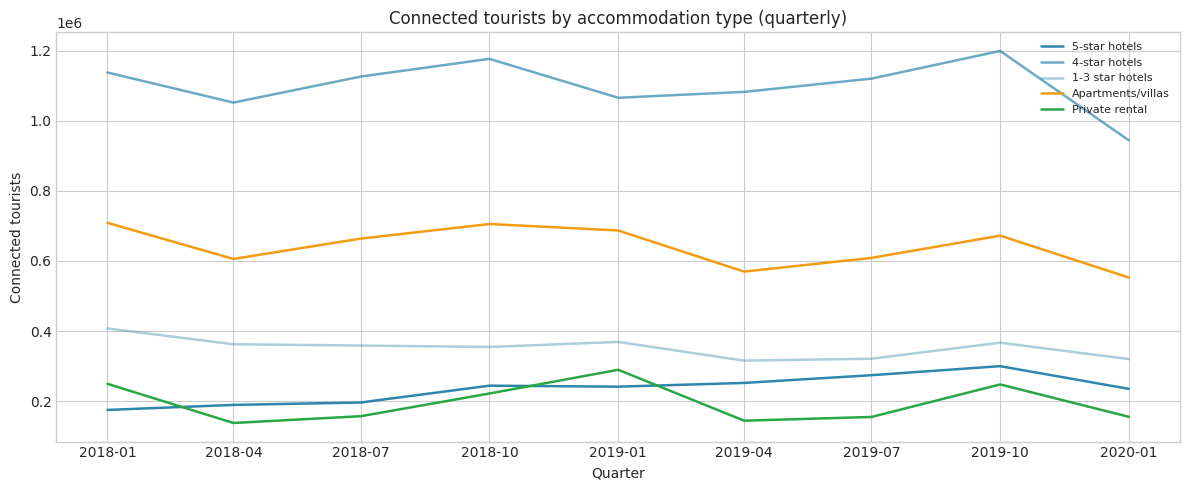

Saved: output/figures/tourist_digital_by_accommodation.png


In [4]:
# 2. Connected tourists by accommodation type - quarterly
fig, ax = plt.subplots(figsize=(12, 5))

acc_types = [
    ("HOTEL_ESTRELLAS_5", "5-star hotels", "#2E86AB"),
    ("HOTEL_ESTRELLAS_4", "4-star hotels", "#2E86AB", 0.7),
    ("HOTEL_ESTRELLAS_S1", "1-3 star hotels", "#2E86AB", 0.4),
    ("APARTAMENTO_VILLA", "Apartments/villas", "#F39C12"),
    ("VIVIENDA_HABITACION_ALQUILADA_PARTICULAR", "Private rental", "#28A745"),
]

for item in acc_types:
    code, label, color = item[0], item[1], item[2]
    alpha = item[3] if len(item) > 3 else 1.0
    d = df[(df["accommodation_code"] == code) & (df["connection_code"] == "SI") & (df["is_quarter"] == True)].dropna(subset=["date"]).sort_values("date")
    if len(d) > 0:
        ax.plot(d["date"], d["tourists"], label=label, color=color, linewidth=1.8, alpha=alpha)

ax.set_xlabel("Quarter")
ax.set_ylabel("Connected tourists")
ax.set_title("Connected tourists by accommodation type (quarterly)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tourist_digital_by_accommodation.png", dpi=150)
plt.show()
print("Saved: output/figures/tourist_digital_by_accommodation.png")

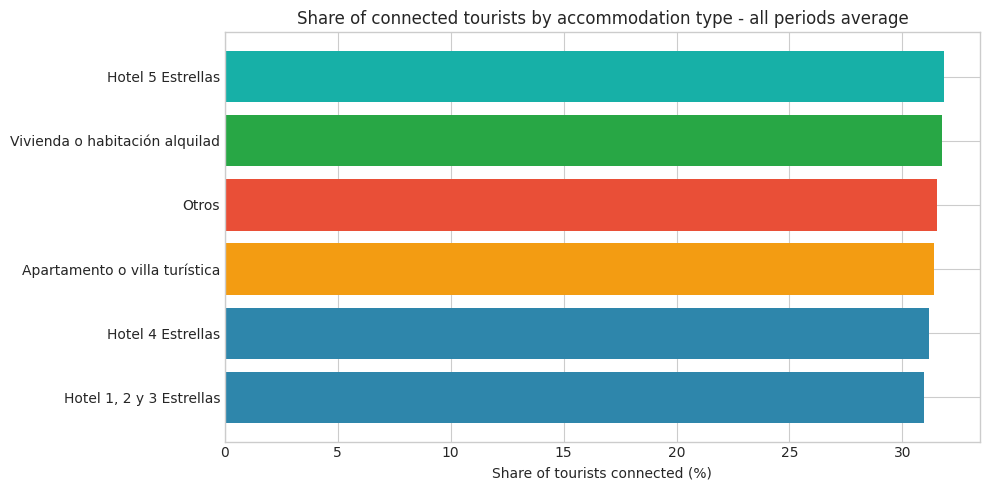

Saved: output/figures/tourist_digital_share_by_accommodation.png


In [5]:
# 3. Share of connected tourists by accommodation type - all periods average
non_total = df[(df["accommodation_code"] != "_T") & (df["connection_code"] != "Total")]
connected = non_total[non_total["connection_code"] == "SI"].groupby("accommodation")["tourists"].sum()
total_per_acc = non_total.groupby("accommodation")["tourists"].sum()
share = (connected / total_per_acc * 100).dropna().sort_values(ascending=True)
share = share[~share.index.str.contains("Vivienda de amigos", na=False)]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2E86AB", "#2E86AB", "#F39C12", "#E94F37", "#28A745", "#17B0A7"]
ax.barh(range(len(share)), share.values, color=colors[:len(share)])
ax.set_yticks(range(len(share)))
ax.set_yticklabels([x[:30] for x in share.index])
ax.set_xlabel("Share of tourists connected (%)")
ax.set_title("Share of connected tourists by accommodation type - all periods average")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tourist_digital_share_by_accommodation.png", dpi=150)
plt.show()
print("Saved: output/figures/tourist_digital_share_by_accommodation.png")

In [6]:
# 4. Key numbers
print("Connected tourists by accommodation (all periods):")
connected_sum = df[(df["accommodation_code"] != "_T") & (df["connection_code"] == "SI")].groupby("accommodation")["tourists"].sum().sort_values(ascending=False)
total_per_acc2 = df[(df["accommodation_code"] != "_T") & (df["connection_code"] != "Total")].groupby("accommodation")["tourists"].sum()
for acc, val in connected_sum.items():
    total_val = total_per_acc2.get(acc, 0)
    pct = val / total_val * 100 if total_val > 0 else 0
    print("  " + acc[:35] + ": " + str(int(val)) + " (" + str(round(pct, 1)) + "% connected)")

print()
print("Q1 2020 vs Q1 2019 total connected tourists:")
for q in ["2019-Q1", "2020-Q1"]:
    val = df[(df["period"] == q) & (df["accommodation_code"] == "_T") & (df["connection_code"] == "SI")]["tourists"].values
    print("  " + q + ": " + str(int(val[0])) if len(val) > 0 else "  " + q + ": N/A")

Connected tourists by accommodation (all periods):
  Hotel 4 Estrellas: 19815021 (31.2% connected)
  Apartamento o villa turística: 11550419 (31.4% connected)
  Hotel 1, 2 y 3 Estrellas: 6350336 (30.9% connected)
  Vivienda de amigos o familiares o v: 4243426 (31.1% connected)
  Hotel 5 Estrellas: 4211860 (31.8% connected)
  Otros: 4077082 (31.5% connected)
  Vivienda o habitación alquilada a u: 3513013 (31.7% connected)

Q1 2020 vs Q1 2019 total connected tourists:
  2019-Q1: 3238298
  2020-Q1: 2539666
